# 01 — Data Audit & Exploratory Data Analysis

**Dataset:** WHO Life Expectancy dataset (2,938 rows, 22 columns, 193 countries, 2000–2015)

**Goal of this notebook:** understand what we're working with before making any cleaning decisions — shape, types, missingness, duplicates, distributions, outliers, and relationships with the target (`life_expectancy`). No values are changed here; this is diagnostic only.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.insert(0, '../src')
from utils import load_raw

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

df = load_raw()
print(df.shape)
df.head()

(2938, 22)


,country,year,status,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,bmi,under_five_deaths,polio,total_expenditure,diphtheria,hiv_aids,gdp,population,thinness_10_19_years,thinness_5_9_years,income_composition,schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


## Basic structure

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   country                 2938 non-null   str    
 1   year                    2938 non-null   int64  
 2   status                  2938 non-null   str    
 3   life_expectancy         2928 non-null   float64
 4   adult_mortality         2928 non-null   float64
 5   infant_deaths           2938 non-null   int64  
 6   alcohol                 2744 non-null   float64
 7   percentage_expenditure  2938 non-null   float64
 8   hepatitis_b             2385 non-null   float64
 9   measles                 2938 non-null   int64  
 10  bmi                     2904 non-null   float64
 11  under_five_deaths       2938 non-null   int64  
 12  polio                   2919 non-null   float64
 13  total_expenditure       2712 non-null   float64
 14  diphtheria              2919 non-null   float64
 15

## Duplicate rows
Checking for exact duplicate rows, and duplicate (country, year) pairs which would indicate a data entry problem (each country-year should be unique).

In [3]:
print('Exact duplicate rows:', df.duplicated().sum())
print('Duplicate (country, year) pairs:', df.duplicated(subset=['country','year']).sum())
print('Countries:', df['country'].nunique())
print('Year range:', df['year'].min(), '-', df['year'].max())
print('Status categories:', df['status'].unique())

Exact duplicate rows: 0
Duplicate (country, year) pairs: 0
Countries: 193
Year range: 2000 - 2015
Status categories: <StringArray>
['Developing', 'Developed']
Length: 2, dtype: str


## Missing value audit
Counting and visualizing missingness per column. This directly drives our imputation strategy in notebook 02.

In [4]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_table = missing_table[missing_table['missing_count'] > 0]
missing_table

,missing_count,missing_pct
population,652,22.19
hepatitis_b,553,18.82
gdp,448,15.25
total_expenditure,226,7.69
alcohol,194,6.60
income_composition,167,5.68
schooling,163,5.55
thinness_10_19_years,34,1.16
thinness_5_9_years,34,1.16
bmi,34,1.16


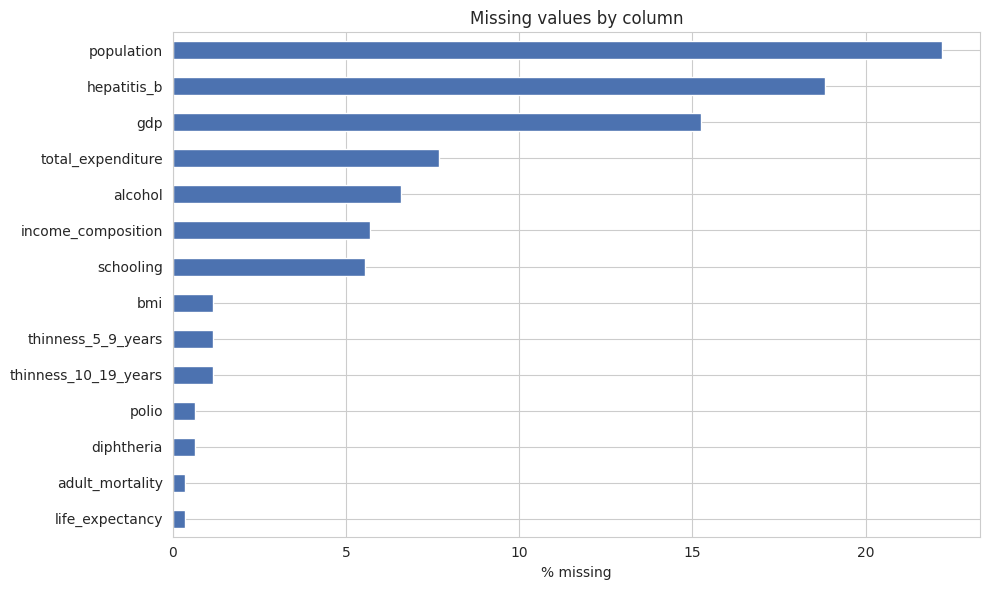

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
missing_table['missing_pct'].sort_values().plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_xlabel('% missing')
ax.set_title('Missing values by column')
plt.tight_layout()
plt.savefig('../figures/01_missing_values.png', dpi=120)
plt.show()

**Observation:** `population`, `hepatitis_b`, `gdp`, and `total_expenditure` have the most missingness (15–34%). Missingness looks structural rather than random — it's concentrated in specific country-year combinations (often smaller/lower-reporting-capacity nations), which we'll confirm below.

In [6]:
# Which countries account for most of the missing data?
rows_with_na = df[df.isnull().any(axis=1)]
rows_with_na['country'].value_counts().head(10)

country
Antigua and Barbuda                 16
Bahamas                             16
Bahrain                             16
Barbados                            16
Bolivia (Plurinational State of)    16
Brunei Darussalam                   16
Côte d'Ivoire                       16
Congo                               16
Cuba                                16
Czechia                             16
Name: count, dtype: int64

## Descriptive statistics
Summary statistics for all numeric columns — this is where we start spotting implausible values (e.g. immunization coverage figures over 100, which is a known quirk of this dataset).

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,2938.0,2.007519e+03,4.613841e+00,2000.00000,2004.000000,2.008000e+03,2.012000e+03,2.015000e+03
life_expectancy,2928.0,6.922493e+01,9.523867e+00,36.30000,63.100000,7.210000e+01,7.570000e+01,8.900000e+01
adult_mortality,2928.0,1.647964e+02,1.242921e+02,1.00000,74.000000,1.440000e+02,2.280000e+02,7.230000e+02
infant_deaths,2938.0,3.030395e+01,1.179265e+02,0.00000,0.000000,3.000000e+00,2.200000e+01,1.800000e+03
alcohol,2744.0,4.602861e+00,4.052413e+00,0.01000,0.877500,3.755000e+00,7.702500e+00,1.787000e+01
percentage_expenditure,2938.0,7.382513e+02,1.987915e+03,0.00000,4.685343,6.491291e+01,4.415341e+02,1.947991e+04
hepatitis_b,2385.0,8.094046e+01,2.507002e+01,1.00000,77.000000,9.200000e+01,9.700000e+01,9.900000e+01
measles,2938.0,2.419592e+03,1.146727e+04,0.00000,0.000000,1.700000e+01,3.602500e+02,2.121830e+05
bmi,2904.0,3.832125e+01,2.004403e+01,1.00000,19.300000,4.350000e+01,5.620000e+01,8.730000e+01
under_five_deaths,2938.0,4.203574e+01,1.604455e+02,0.00000,0.000000,4.000000e+00,2.800000e+01,2.500000e+03


**Observation:** `hepatitis_b`, `polio`, and `diphtheria` (immunization coverage %) have max values up to 99 which is plausible, but `measles` cases and `infant_deaths`/`under_five_deaths` are heavily right-skewed (max values thousands of times the median) — these are count variables with extreme outliers, not necessarily data errors, that we'll need to handle (likely log-transform) in preprocessing.

## Target variable: life expectancy

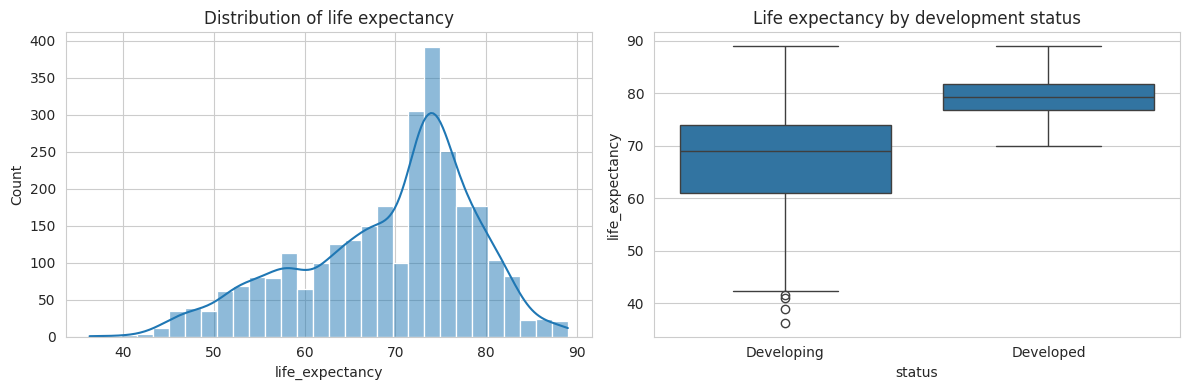

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['life_expectancy'].dropna(), kde=True, ax=axes[0])
axes[0].set_title('Distribution of life expectancy')
sns.boxplot(x='status', y='life_expectancy', data=df, ax=axes[1])
axes[1].set_title('Life expectancy by development status')
plt.tight_layout()
plt.savefig('../figures/02_target_distribution.png', dpi=120)
plt.show()

**Observation:** Life expectancy is left-skewed with a long low tail (a handful of countries/years with life expectancy below 45 — worth checking as possible outliers/data issues in preprocessing). Developed countries show a visibly higher and tighter distribution than developing ones, confirming `status` is a meaningful predictor.

## Outlier scan across numeric features
Boxplots for every numeric column, scaled for visibility, to see which features have heavy outlier tails.

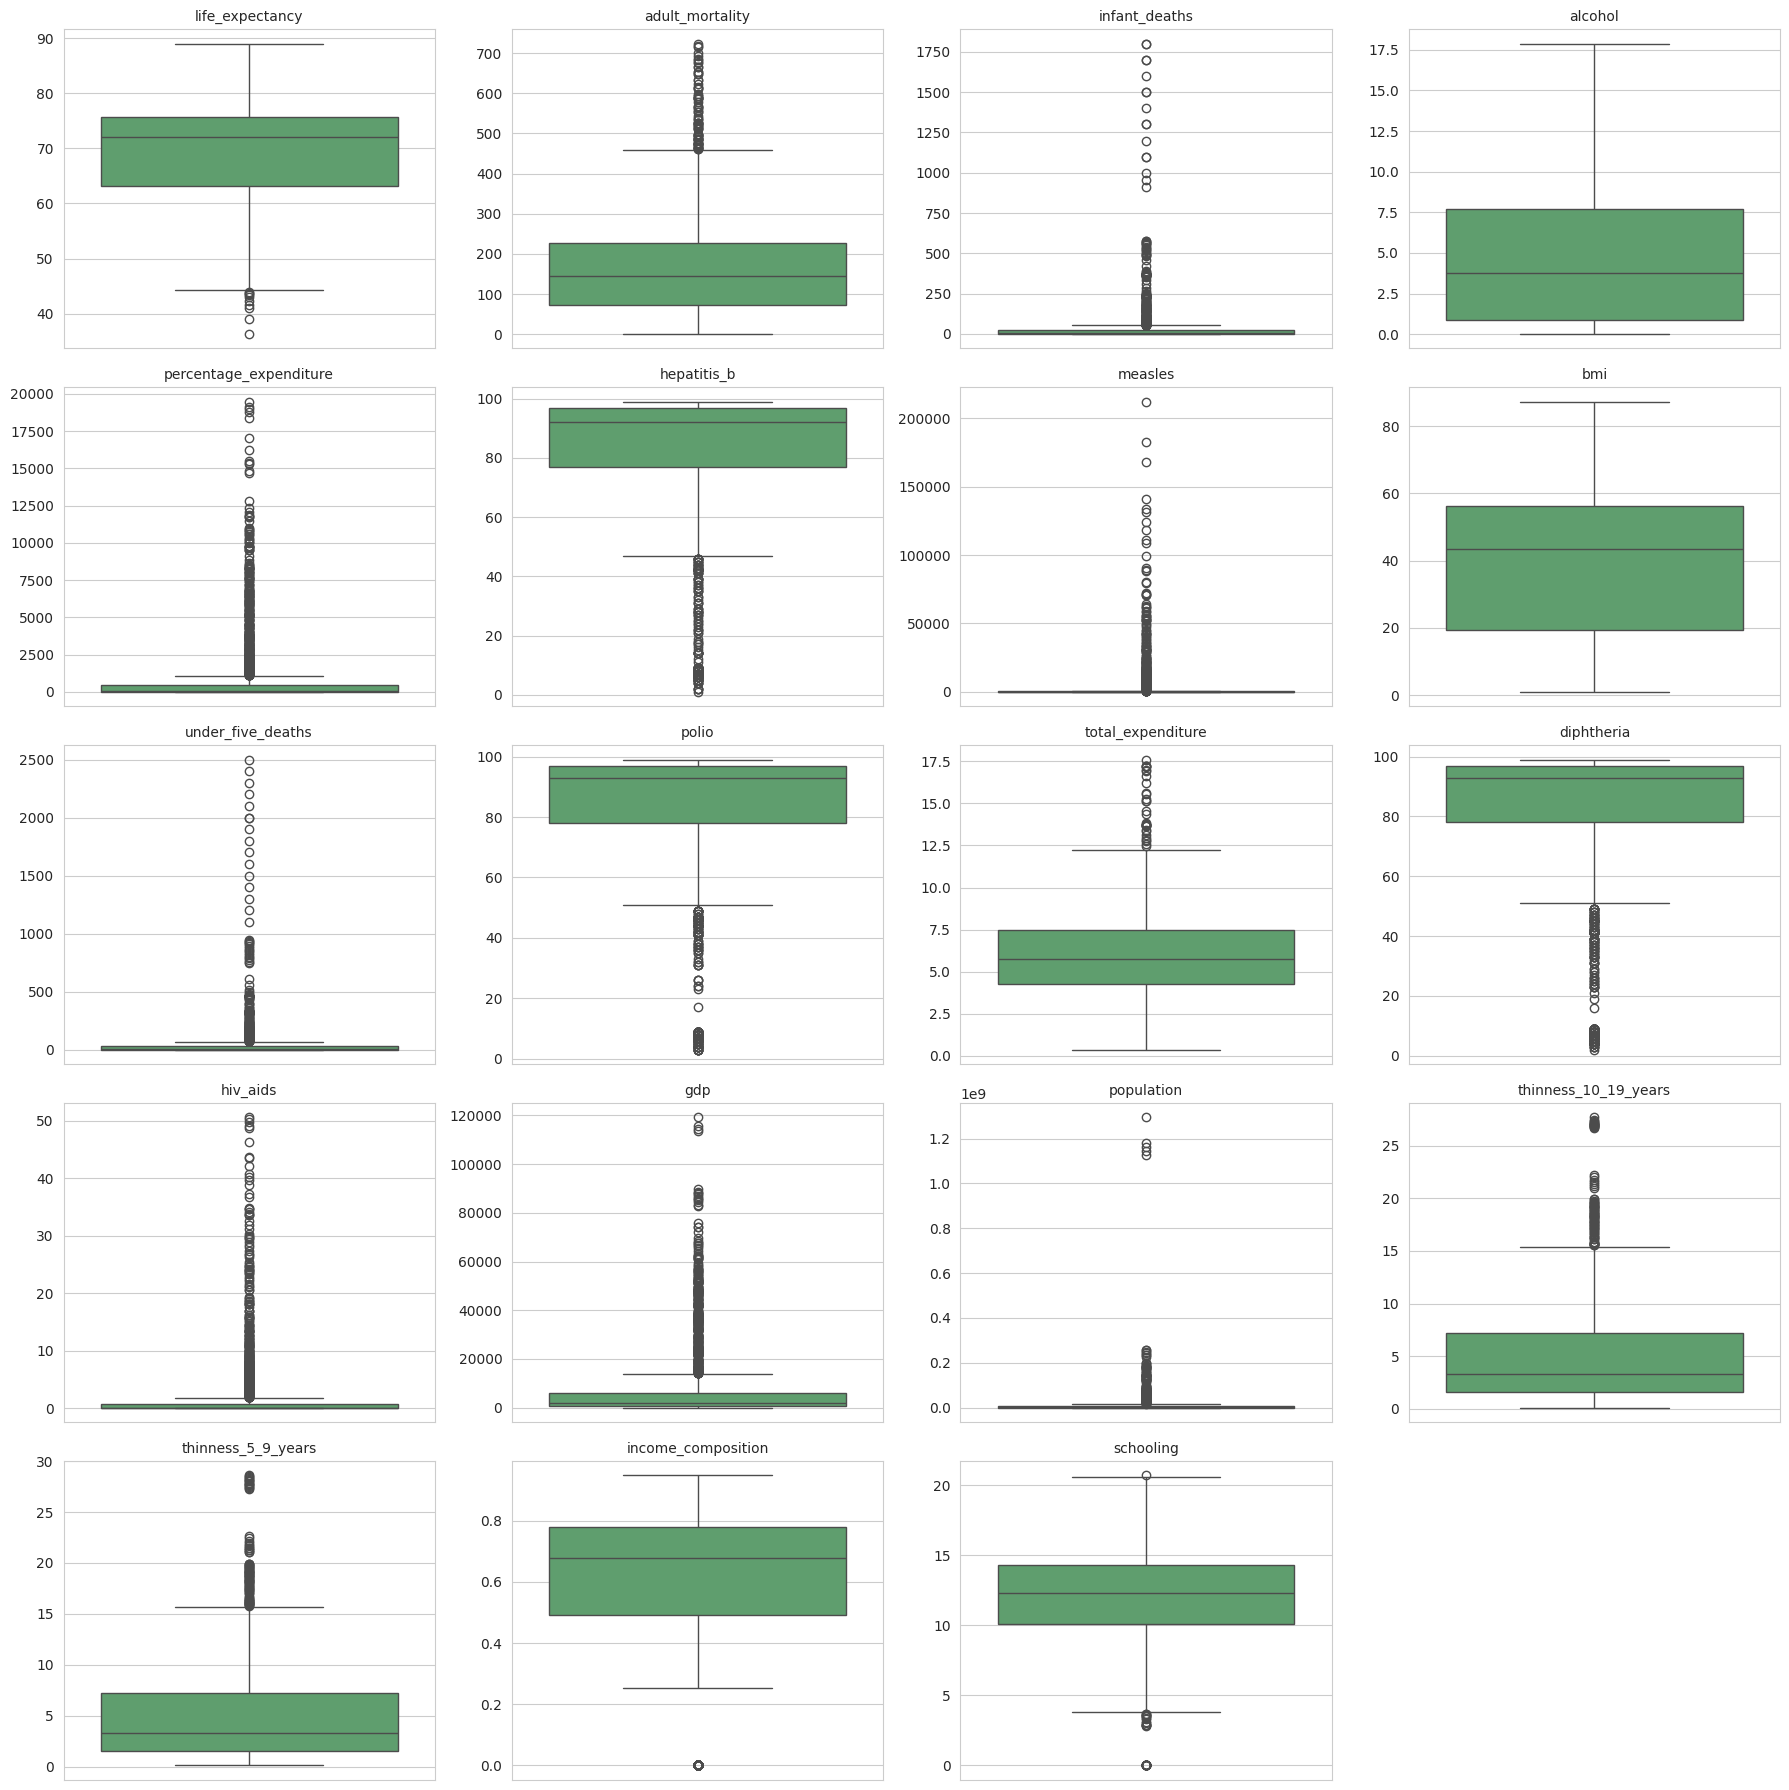

In [9]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop(['year'])
fig, axes = plt.subplots(5, 4, figsize=(18, 18))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='#55A868')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('')
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig('../figures/03_outlier_boxplots.png', dpi=120)
plt.show()

## Correlation with target
Which raw features correlate most strongly (linearly) with life expectancy? This is a first pass — feature selection in notebook 03 will do this more rigorously.

In [10]:
corr = df.select_dtypes(include=[np.number]).corr()
target_corr = corr['life_expectancy'].drop('life_expectancy').sort_values(key=abs, ascending=False)
target_corr

schooling                 0.751975
income_composition        0.724776
adult_mortality          -0.696359
bmi                       0.567694
hiv_aids                 -0.556556
diphtheria                0.479495
thinness_10_19_years     -0.477183
thinness_5_9_years       -0.471584
polio                     0.465556
gdp                       0.461455
alcohol                   0.404877
percentage_expenditure    0.381864
hepatitis_b               0.256762
under_five_deaths        -0.222529
total_expenditure         0.218086
infant_deaths            -0.196557
year                      0.170033
measles                  -0.157586
population               -0.021538
Name: life_expectancy, dtype: float64

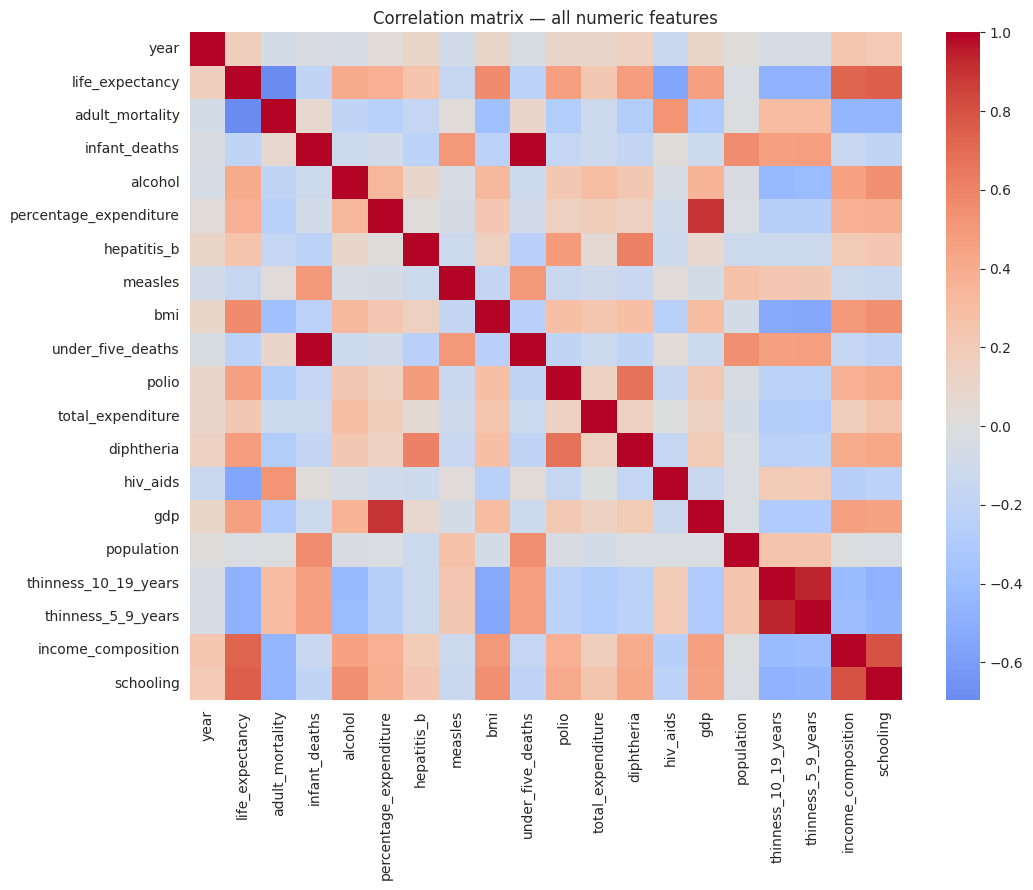

In [11]:
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, ax=ax)
ax.set_title('Correlation matrix — all numeric features')
plt.tight_layout()
plt.savefig('../figures/04_correlation_heatmap.png', dpi=120)
plt.show()

## Key takeaways for preprocessing (notebook 02)
1. **Missingness is uneven and structural**, concentrated in specific countries — simple global-mean imputation would be crude. We'll impute **within country** (forward/backward fill across years) before falling back to group-level medians.
2. **Right-skewed count variables** (`measles`, `infant_deaths`, `under_five_deaths`, `population`, `gdp`, `percentage_expenditure`) need a log transform.
3. **A handful of rows have implausibly low life expectancy** (<45) that need inspection — some may be legitimate (conflict-affected countries) rather than errors.
4. **`adult_mortality`, `income_composition`, and `schooling`** show the strongest correlation with the target and will likely be important features.
5. **`hiv_aids` and `adult_mortality`** correlate with each other as well as the target — worth watching for multicollinearity during feature selection.